In [49]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB1
from tensorflow.keras.optimizers import Adam

In [50]:
data_path = "/kaggle/input/datasets/meetnagadia/kvasir-dataset/kvasir-dataset"

classes = os.listdir(data_path)
print(classes)

['dyed-lifted-polyps', 'normal-z-line', 'dyed-resection-margins', 'normal-pylorus', 'normal-cecum', 'polyps', 'ulcerative-colitis', 'esophagitis']


In [51]:
for cls in classes:
    print(cls, ":", len(os.listdir(os.path.join(data_path, cls))))

dyed-lifted-polyps : 500
normal-z-line : 500
dyed-resection-margins : 500
normal-pylorus : 500
normal-cecum : 500
polyps : 500
ulcerative-colitis : 500
esophagitis : 500


In [52]:
img_size = (224, 224)
batch_size = 32

# (Train + Validation)
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=img_size,
    batch_size=batch_size
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=img_size,
    batch_size=batch_size
)


#  Val + Test

val_batches = tf.data.experimental.cardinality(val_ds)

test_ds = val_ds.take(val_batches // 2)
val_ds = val_ds.skip(val_batches // 2)


print("Train batches:", tf.data.experimental.cardinality(train_ds))
print("Validation batches:", tf.data.experimental.cardinality(val_ds))
print("Test batches:", tf.data.experimental.cardinality(test_ds))

class_names = train_ds.class_names
print("Classes:", class_names)

Found 4000 files belonging to 8 classes.
Using 3200 files for training.
Found 4000 files belonging to 8 classes.
Using 800 files for validation.
Train batches: tf.Tensor(100, shape=(), dtype=int64)
Validation batches: tf.Tensor(13, shape=(), dtype=int64)
Test batches: tf.Tensor(12, shape=(), dtype=int64)
Classes: ['dyed-lifted-polyps', 'dyed-resection-margins', 'esophagitis', 'normal-cecum', 'normal-pylorus', 'normal-z-line', 'polyps', 'ulcerative-colitis']


In [53]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [54]:
for images, labels in train_ds.take(1):
    print(images.shape)
    print(labels.shape)

(32, 224, 224, 3)
(32,)


In [55]:
# Data Augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2)
])


# Preprocessing
preprocess = tf.keras.applications.efficientnet.preprocess_input

# Base Model
base_model = EfficientNetB1(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

# Fine-Tuning

base_model.trainable = True

for layer in base_model.layers[:-80]:   
    layer.trainable = False

# Full Model

model = models.Sequential([
    data_augmentation,
    layers.Lambda(preprocess),  
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),   
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(8, activation='softmax')
])

# Compile
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_1 (Lambda)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb1 (Functional)     │ (None, 7, 7, 1280)     │     6,575,239 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,575,239 (25.08 MB)

 Trainable params: 4,678,416 (17.85 MB)

 Non-trainable params: 1,896,823 (7.24 MB)

In [56]:
lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=2,
    verbose=1
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True
)

In [57]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[lr_scheduler, early_stop]
)

Epoch 1/20


E0000 00:00:1777733883.101566      57 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/sequential_3_1/efficientnetb1_1/block1b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


100/100 ━━━━━━━━━━━━━━━━━━━━ 45s 210ms/step - accuracy: 0.3855 - loss: 1.9255 - val_accuracy: 0.7788 - val_loss: 0.8172 - learning_rate: 1.0000e-04
Epoch 2/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 16s 157ms/step - accuracy: 0.7710 - loss: 0.6060 - val_accuracy: 0.8341 - val_loss: 0.5099 - learning_rate: 1.0000e-04
Epoch 3/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 16s 155ms/step - accuracy: 0.8452 - loss: 0.4335 - val_accuracy: 0.8365 - val_loss: 0.4544 - learning_rate: 1.0000e-04
Epoch 4/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 154ms/step - accuracy: 0.8696 - loss: 0.3337 - val_accuracy: 0.8438 - val_loss: 0.4346 - learning_rate: 1.0000e-04
Epoch 5/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 16s 155ms/step - accuracy: 0.8984 - loss: 0.2587 - val_accuracy: 0.8606 - val_loss: 0.4143 - learning_rate: 1.0000e-04
Epoch 6/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 155ms/step - accuracy: 0.9196 - loss: 0.2182 - val_accuracy: 0.8606 - val_loss: 0.4237 - learning_rate: 1.0000e-04
Epoch 7/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - a

In [58]:
test_loss, test_acc = model.evaluate(test_ds)

print("Test Accuracy:", test_acc)

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 106ms/step - accuracy: 0.9097 - loss: 0.3213
Test Accuracy: 0.8984375


In [59]:
class_names = sorted(os.listdir(data_path))
print(class_names)

['dyed-lifted-polyps', 'dyed-resection-margins', 'esophagitis', 'normal-cecum', 'normal-pylorus', 'normal-z-line', 'polyps', 'ulcerative-colitis']


In [71]:
def predict_image(img_path, model, class_names):
    from tensorflow.keras.preprocessing import image
    import numpy as np

    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    preds = model.predict(img_array)

    pred_index = np.argmax(preds[0])
    confidence = preds[0][pred_index]

    pred_class = class_names[pred_index]

    return pred_class, confidence, img_array

In [72]:
# class_name = "esophagitis"  
# folder = os.path.join(data_path, class_name)

# img_name = os.listdir(folder)[199] 
# img_path = os.path.join(folder, img_name)

# print(img_path)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step


(np.float64(-0.5), np.float64(491.5), np.float64(427.5), np.float64(-0.5))

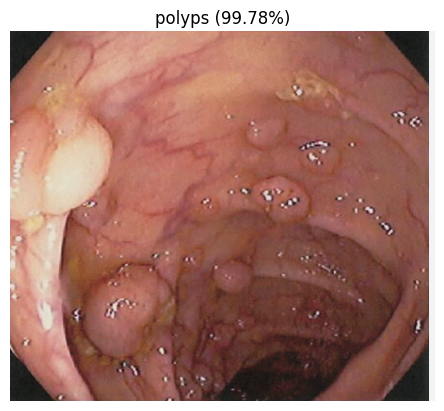

In [73]:
img_path = "/kaggle/input/datasets/ranaahmed202201899/test-img/Screenshot 2026-05-02 130239.png"
pred_class, conf, img_array = predict_image(img_path, model, class_names)

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.title(f"{pred_class} ({conf*100:.2f}%)")
plt.axis("off")

# **Grad-CAM**

In [74]:
base_model = model.get_layer("efficientnetb1")

In [75]:
feature_extractor = tf.keras.Model(
    inputs=base_model.input,
    outputs=base_model.get_layer("top_conv").output
)

In [76]:
x = tf.keras.Input(shape=(7, 7, 1280))

y = tf.keras.layers.GlobalAveragePooling2D()(x)

y = model.layers[-3](y)  
y = model.layers[-2](y)   
y = model.layers[-1](y)   

classifier = tf.keras.Model(x, y)

In [77]:
def gradcam(img_array):

    img_tensor = tf.cast(img_array, tf.float32)

    with tf.GradientTape() as tape:
        features = feature_extractor(img_tensor)
        preds = classifier(features)

        pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, features)

    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    features = features[0]

    heatmap = features @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.reduce_max(heatmap)

    return heatmap.numpy()

In [78]:
from tensorflow.keras.preprocessing import image
import numpy as np

img_path = "/kaggle/input/datasets/ranaahmed202201899/test-img/Screenshot 2026-05-02 130239.png"

img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

In [79]:
heatmap = gradcam(img_array)

In [80]:
risk_map = {
    "polyps": "High",
    "ulcerative-colitis": "High",
    "esophagitis": "Medium",
    "dyed-lifted-polyps": "Medium",
    "dyed-resection-margins": "Low",
    "normal-cecum": "Low",
    "normal-pylorus": "Low",
    "normal-z-line": "Low"
}

In [81]:
def show_result(img_path, model, class_names):
    
    # Prediction
    pred_class, conf, img_array = predict_image(img_path, model, class_names)

    # Risk
    risk = risk_map[pred_class]

    # Heatmap
    heatmap = gradcam(img_array)

    # Load image
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Heatmap overlay
    heatmap_resized = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap_resized = np.uint8(255 * heatmap_resized)
    heatmap_resized = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)

    superimposed_img = heatmap_resized * 0.4 + img

    # Display
    plt.figure(figsize=(8,6))
    plt.imshow(superimposed_img.astype("uint8"))
    plt.axis("off")

    plt.title(
        f"Class: {pred_class} | Confidence: {conf*100:.2f}% | Risk: {risk}",
        fontsize=12
    )

    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step


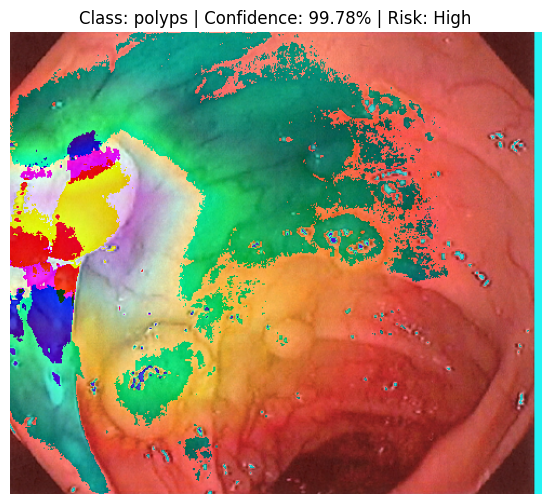

In [82]:
show_result(img_path, model, class_names)

In [83]:
model.save("gi_model.keras")